# Machine Learning — Homework 3: Trees, Ensembles and SVMs

**Course:** Machine Learning — National University of Kyiv-Mohyla Academy (NaUKMA)
**Instructor:** Dmytro Kuzmenko (kuzmenko@ukma.edu.ua)
**Module:** Weeks 4–5 — *"Trees and Ensembles"* + *"Margins, Similarity and Kernels"*

## Meta

- **Points:** 5 (Homework 3 of 6; homeworks total 30% of the final grade)
- **Estimated time:** 2.5–3.5 hours
- **Prerequisites:** Weeks 4–5. Python, `numpy`, `matplotlib`, `scikit-learn` (decision trees, random forests, gradient boosting, SVM, cross-validation).
- **Deadline:** [to be announced by the instructor]
- **Submission:** one executed `.ipynb` file with the AI Use Disclosure completed.
- **Late policy:** 5 free late days across all homeworks; 1 late day = up to 24 h; after that, −25% of the maximum per additional 24 h.

## AI Use Disclosure

Policy: AI tools are allowed for homeworks, but you must disclose their use and remain responsible for every claim in your submission. On the midterm and final, AI and external help are forbidden.

- **AI tools used:** ...
- **Nature of assistance:** ...
- **Representative prompts or relevant interaction:** ...
- **What I independently verified or changed:** ...

## Learning Objectives

- Read a tree-complexity curve and extract an interpretable rule from a shallow tree.
- Explain how bagging reduces variance and how boosting trades bias against variance.
- Compare three model families with a fixed train/validation/test protocol and decide with evidence.
- Demonstrate the role of feature scaling for SVMs and the meaning of C and gamma.

# Warm-up

Dataset: `breast_cancer` from scikit-learn — 569 samples, 30 features, binary target (malignant / benign). It loads locally, so no downloads are required. The split is stratified 60 / 20 / 20 (train / validation / test) with a fixed seed.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

data = load_breast_cancer()
X, y = data.data, data.target
print("Samples:", X.shape[0], "| Features:", X.shape[1])
print("Classes:", data.target_names, "-> 1 =", data.target_names[1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print("Prevalence of class 1 — train: {:.3f}, validation: {:.3f}, test: {:.3f}".format(
    y_train.mean(), y_val.mean(), y_test.mean()))
print("Feature ranges: min {:.2f}, max {:.2f}  (scaling will matter for SVMs)".format(X.min(), X.max()))

Samples: 569 | Features: 30
Classes: ['malignant' 'benign'] -> 1 = benign
Prevalence of class 1 — train: 0.627, validation: 0.626, test: 0.629
Feature ranges: min 0.00, max 4254.00  (scaling will matter for SVMs)


# Guided Exercise

## Task 1: Decision tree complexity

Fit decision trees with `max_depth` in [1, 2, 4, 8, None]. For each depth, report train accuracy and 5-fold cross-validated accuracy on the training set; plot the complexity curve. Then plot the depth-2 tree and read one rule out loud.

**Experiment (A).** Sweep the depth:

In [2]:
depths = [1, 2, 4, 8, None]
rows = []
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    cv_acc = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                             X_train, y_train, cv=5).mean()
    rows.append({"max_depth": str(d), "train_acc": train_acc, "cv_acc": cv_acc})
df_tree = pd.DataFrame(rows)
df_tree

,max_depth,train_acc,cv_acc
0,1,0.937304,0.937302
1,2,0.962382,0.949950
2,4,0.984326,0.943700
3,8,0.996865,0.924802
4,None,1.000000,0.924802


**Evidence (C).** Complexity curve and the depth-2 tree:

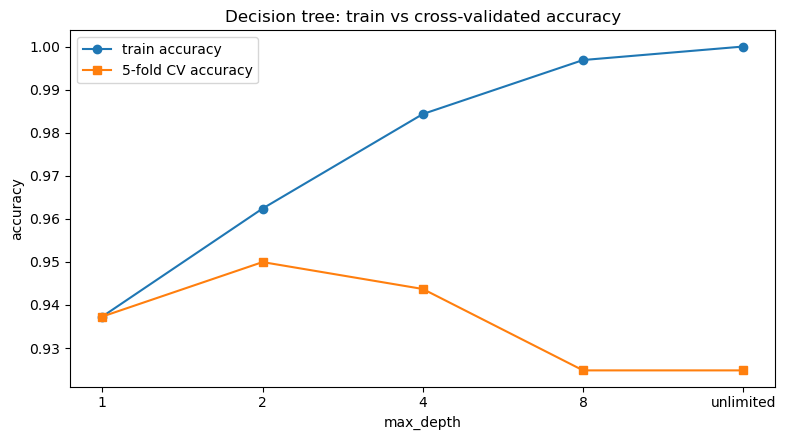

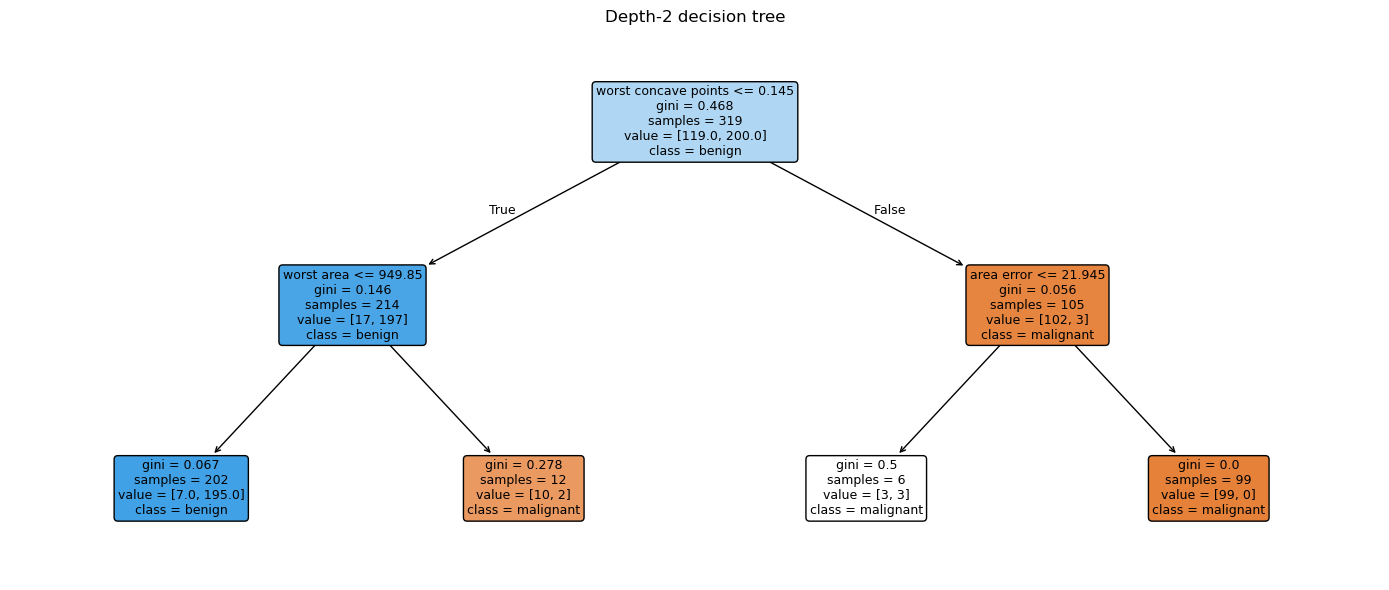

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ["1", "2", "4", "8", "unlimited"]
ax.plot(labels, df_tree["train_acc"], "o-", label="train accuracy")
ax.plot(labels, df_tree["cv_acc"], "s-", label="5-fold CV accuracy")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Decision tree: train vs cross-validated accuracy")
ax.legend()
plt.tight_layout()
plt.show()

tree2 = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(tree2, feature_names=data.feature_names, class_names=data.target_names,
          filled=True, rounded=True, ax=ax, fontsize=9)
ax.set_title("Depth-2 decision tree")
plt.tight_layout()
plt.show()

**Interpretation (D).** Interpret the curve: where does overfitting start and how do you know? Read one rule from the depth-2 tree aloud in plain language (e.g., "if feature X is below/above value ... then the sample is ...").

**Your answer:**

**Decision (B).** Which `max_depth` would you choose for deployment and why? Would you ever choose the depth with the highest train accuracy?

**Your answer:**

**Counterfactual (E).** If you constrained `min_samples_leaf` instead of `max_depth`, what would change about the trees and about the bias–variance balance? What if the classes were strongly imbalanced?

**Your answer:**

## Task 2: Random forest vs a single tree

Compare the best single tree (depth 2) with random forests of 10, 50, and 200 trees. Report 5-fold CV accuracy on the training set, plus train and validation accuracy.

**Experiment (A).** Sweep the number of trees:

In [4]:
rows = []
for ne in [10, 50, 200]:
    model = RandomForestClassifier(n_estimators=ne, random_state=42, n_jobs=-1)
    cv_acc = cross_val_score(model, X_train, y_train, cv=5).mean()
    model.fit(X_train, y_train)
    rows.append({"model": f"RF ({ne} trees)",
                 "cv_acc": cv_acc,
                 "train_acc": accuracy_score(y_train, model.predict(X_train)),
                 "val_acc": accuracy_score(y_val, model.predict(X_val))})

tree_row = {"model": "tree (depth 2)",
            "cv_acc": cross_val_score(DecisionTreeClassifier(max_depth=2, random_state=42),
                                      X_train, y_train, cv=5).mean(),
            "train_acc": accuracy_score(y_train, tree2.predict(X_train)),
            "val_acc": accuracy_score(y_val, tree2.predict(X_val))}
df_rf = pd.DataFrame([tree_row] + rows)
df_rf

,model,cv_acc,train_acc,val_acc
0,tree (depth 2),0.949950,0.962382,0.934579
1,RF (10 trees),0.940526,0.996865,0.981308
2,RF (50 trees),0.953026,1.000000,0.962617
3,RF (200 trees),0.956151,1.000000,0.953271


**Evidence (C).** Bar chart of train vs validation accuracy:

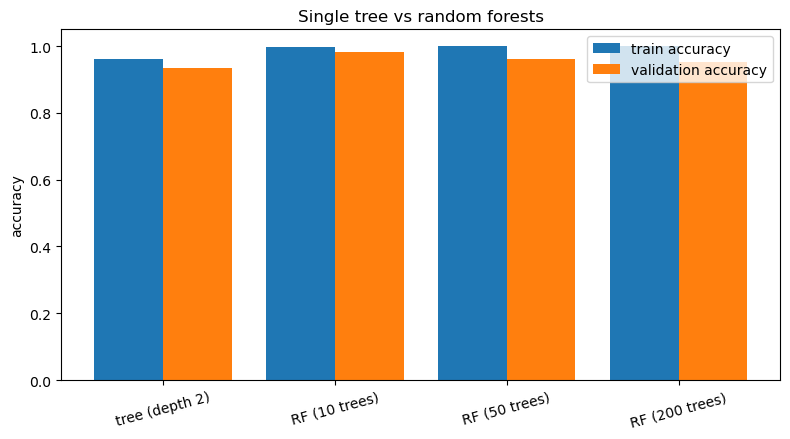

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xpos = np.arange(len(df_rf))
ax.bar(xpos - 0.2, df_rf["train_acc"], 0.4, label="train accuracy")
ax.bar(xpos + 0.2, df_rf["val_acc"], 0.4, label="validation accuracy")
ax.set_xticks(xpos)
ax.set_xticklabels(df_rf["model"], rotation=15)
ax.set_ylabel("accuracy")
ax.set_title("Single tree vs random forests")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (D).** Why does the forest beat the single tree even though each tree is trained on (a bootstrap of) the same data? Explain bagging: averaging over trees reduces what exactly — bias, variance, or both?

**Your answer:**

**Counterfactual (E).** If the forest used fully random splits (extreme randomness, as in Extra-Trees), predict the effect on bias and variance and on the sensitivity to individual noisy features. Also: why does CV accuracy keep growing slowly from 10 to 200 trees while train accuracy saturates at 1.0?

**Your answer:**

# Discussion Questions

Answer both questions briefly (2–4 sentences each).

**Question 1.** Cross-validation accuracy of the depth-2 tree (0.950) is close to that of depth 4 (0.944). Which estimate would you trust more, and what additional evidence would you collect before deployment?

**Your answer:**

**Question 2.** Decision trees are often called high-variance models. What exactly varies when you retrain a tree on a new sample — predictions, the chosen splits, or both?

**Your answer:**

# Challenge

## Task 3: Gradient boosting vs random forest vs tree

Fit a gradient-boosted classifier (200 trees, learning rate 0.05, depth 2) and compare it with RF (200 trees) and the depth-2 tree using a train/validation/test table.

**Experiment (A).** Build the comparison table (test is evaluated exactly once, at the end):

In [6]:
models = {
    "tree (depth 2)": DecisionTreeClassifier(max_depth=2, random_state=42),
    "random forest (200)": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "gradient boosting (200)": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                          max_depth=2, random_state=42),
}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    rows.append({
        "model": name,
        "train_acc": accuracy_score(y_train, model.predict(X_train)),
        "train_f1": f1_score(y_train, model.predict(X_train)),
        "val_acc": accuracy_score(y_val, model.predict(X_val)),
        "val_f1": f1_score(y_val, model.predict(X_val)),
        "test_acc": accuracy_score(y_test, model.predict(X_test)),
        "test_f1": f1_score(y_test, model.predict(X_test)),
    })
df_compare = pd.DataFrame(rows)
df_compare

,model,train_acc,train_f1,val_acc,val_f1,test_acc,test_f1
0,tree (depth 2),0.962382,0.970149,0.934579,0.947368,0.944056,0.956044
1,random forest (200),1.000000,1.000000,0.953271,0.962963,0.951049,0.961326
2,gradient boosting (200),1.000000,1.000000,0.953271,0.962963,0.951049,0.961749


**Decision (B).** Which model would you currently prefer for this problem, and why? What further evidence would you request before committing (e.g., repeated CV, error analysis by class, calibration, training/inference cost)?

**Your answer:**

**Interpretation (D).** Interpret the table: are train/validation/test numbers consistent? Where do the three models differ? Why can boosting reach the same validation score as the forest while building trees sequentially?

**Your answer:**

**Counterfactual (E).** If you raised the number of boosting iterations to 2000 with the same learning rate, what risk appears? If the dataset had 10,000 features with many irrelevant ones, which of the three families would degrade most?

**Your answer:**

## Task 4: SVMs — kernels, scaling, C and gamma

Fit linear and RBF SVMs on raw and standardized features; then sweep C and gamma for the RBF kernel on standardized features and choose a final pipeline.

**Experiment (A).** Kernels × scaling (validation set):

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

svm_configs = {
    "linear, raw": SVC(kernel="linear", random_state=42),
    "RBF, raw": SVC(kernel="rbf", random_state=42),
    "linear, scaled": SVC(kernel="linear", random_state=42),
    "RBF, scaled": SVC(kernel="rbf", random_state=42),
}
rows = []
for name, model in svm_configs.items():
    if name.endswith("scaled"):
        model.fit(X_train_s, y_train)
        val_pred = model.predict(X_val_s)
    else:
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
    rows.append({"config": name,
                 "val_acc": accuracy_score(y_val, val_pred),
                 "val_f1": f1_score(y_val, val_pred)})
df_svm = pd.DataFrame(rows)
df_svm

,config,val_acc,val_f1
0,"linear, raw",0.981308,0.985294
1,"RBF, raw",0.943925,0.957143
2,"linear, scaled",1.000000,1.000000
3,"RBF, scaled",0.971963,0.977778


**Evidence (C).** C × gamma grid for the RBF kernel on scaled features (validation F1):

In [8]:
rows = []
for C in [0.01, 1, 100]:
    for gamma in [0.001, 0.01, 0.1]:
        model = SVC(kernel="rbf", C=C, gamma=gamma, random_state=42).fit(X_train_s, y_train)
        val_pred = model.predict(X_val_s)
        rows.append({"C": C, "gamma": gamma,
                     "val_acc": accuracy_score(y_val, val_pred),
                     "val_f1": f1_score(y_val, val_pred)})
df_grid = pd.DataFrame(rows)
df_grid.pivot(index="gamma", columns="C", values="val_f1").round(3)

C,0.01,1.00,100.00
gamma,,,
0.001,0.77,0.950,0.993
0.010,0.77,0.985,0.985
0.100,0.77,0.954,0.955


**Interpretation (D).** Interpret the scaling effect (raw vs standardized) and the grid: how does C control the margin/error trade-off, and how does gamma control the locality of the RBF kernel? Which cells overfit and which underfit?

**Your answer:**

**Decision (B).** State your final pipeline choice (preprocessing, kernel, C, gamma) and justify it. Is the RBF's extra flexibility worth it compared with the linear SVM on this data?

**Your answer:**

**Counterfactual (E).** If the features had been measured in different units (e.g., one in millimeters, another in kilograms), what would happen without scaling? If the problem had 5,000 features, which kernel would you expect to struggle and why?

**Your answer:**

## Takeaways

- Tree depth is a complexity dial; CV accuracy separates signal from overfitting.
- Bagging (random forest) cuts variance by averaging decorrelated trees; boosting cuts bias by fitting residuals sequentially.
- Model comparison needs a fixed protocol: train/validation/test, plus cross-validated or repeated estimates.
- SVMs are distance-based: scaling is not optional, and C and gamma control the bias–variance trade-off.